# Melting Point 예측 — v3_ann
ANN (MLP) 신경망 | PyTorch + Morgan FP + MACCS + RDKit 기술자

In [25]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn rdkit torch shap -q

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, MACCSkeys
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import platform, subprocess
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams["font.family"] = "NanumGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("라이브러리 로드 완료")
print(f"디바이스: {DEVICE}")

라이브러리 로드 완료
디바이스: cpu


## 1. 데이터 로드 및 정리

In [27]:
df = pd.read_csv("https://raw.githubusercontent.com/sunghee-sketch/middle-test/main/data/Melting_point_2.csv")
df = df.drop_duplicates().reset_index(drop=True)
df = df[df["MP"] >= 0].reset_index(drop=True)  # 음수 MP 제거
df["MP_log"] = np.log1p(df["MP"])
print(f"데이터 크기: {df.shape}")
print(f"MP 범위: {df['MP'].min():.1f} ~ {df['MP'].max():.1f} K")
df.head()

데이터 크기: (2117, 3)
MP 범위: 13.9 ~ 1870.0 K


,SMILES,MP,MP_log
0,CCN(O)CC,247.650,5.516046
1,c1(C(C)=C)ccccc1,249.950,5.525254
2,C/C=C/CCCC,164.000,5.105945
3,c1(CC)cc(CC)cc(CC)c1,206.735,5.336263
4,COC(C)(C)C(=O)OC,229.600,5.440685


## 2. 피처 엔지니어링

In [28]:
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
desc_list  = [(n, f) for n, f in Descriptors.descList if not n.startswith("Ipc")]

def smiles_to_features(smiles_list):
    records, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        morgan = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
        descs  = []
        for _, func in desc_list:
            try:
                v = func(mol)
                descs.append(float(v) if (v is not None and np.isfinite(v)) else 0.0)
            except Exception:
                descs.append(0.0)
        records.append(np.concatenate([morgan, maccs, np.array(descs, np.float32)]))
        valid_idx.append(i)
    X = np.array(records, dtype=np.float32)
    # NaN/Inf 최종 방어
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, valid_idx

print("피처 추출 중...")
X_all, valid_idx = smiles_to_features(df["SMILES"].tolist())
y_all     = df["MP"].values[valid_idx]
y_all_log = df["MP_log"].values[valid_idx]
print(f"유효 샘플: {len(valid_idx)} / {len(df)}")
print(f"피처 차원: {X_all.shape[1]}")
print(f"NaN 개수: {np.isnan(X_all).sum()}  |  Inf 개수: {np.isinf(X_all).sum()}")

피처 추출 중...
유효 샘플: 2117 / 2117
피처 차원: 2431
NaN 개수: 0  |  Inf 개수: 0


## 3. Train/Test 분할 & 스케일링

In [29]:
mp_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")
X_train, X_test, y_train, y_test, y_tr_log, y_te_log = train_test_split(
    X_all, y_all, y_all_log,
    test_size=0.2, random_state=RANDOM_STATE, stratify=mp_bins
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

# 스케일 후 NaN/Inf 방어 및 극단값 클리핑 (폭주 방지)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)
X_train_sc = np.clip(X_train_sc, -10.0, 10.0).astype(np.float32)
X_test_sc  = np.clip(X_test_sc,  -10.0, 10.0).astype(np.float32)

# float32 캐스팅 (torch MSELoss 호환)
y_tr_log = y_tr_log.astype(np.float32)
y_te_log = y_te_log.astype(np.float32)

# 고MP 샘플 가중치
high_thr = np.percentile(y_train, 90)
sw_train = np.where(y_train >= high_thr, 3.0, 1.0).astype(np.float32)

print(f"Train: {X_train_sc.shape[0]}개  |  Test: {X_test_sc.shape[0]}개")
print(f"X_train_sc range: [{X_train_sc.min():.2f}, {X_train_sc.max():.2f}]  |  NaN: {np.isnan(X_train_sc).sum()}")

Train: 1693개  |  Test: 424개
X_train_sc range: [-10.00, 10.00]  |  NaN: 0


## 4. MLP 모델 정의

In [30]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch, w_batch in loader:
        X_batch, y_batch, w_batch = X_batch.to(DEVICE), y_batch.to(DEVICE), w_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = (criterion(pred, y_batch) * w_batch).mean()
        loss.backward()
        # 폭주 방지용 그래디언트 클리핑
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def predict(model, X_sc):
    model.eval()
    X_t = torch.tensor(X_sc).to(DEVICE)
    return model(X_t).cpu().numpy()

INPUT_DIM = X_train_sc.shape[1]
print(f"MLP 입력 차원: {INPUT_DIM}")
print(f"구조: {INPUT_DIM} → 512 → 256 → 128 → 1")

MLP 입력 차원: 2431
구조: 2431 → 512 → 256 → 128 → 1


## 5. 5-Fold Cross Validation

In [31]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mp_bins_train = pd.qcut(y_train, q=10, labels=False, duplicates="drop")
cv_r2, cv_mse, cv_mae = [], [], []

EPOCHS    = 150
BATCH     = 64
LR        = 1e-3
PATIENCE  = 20

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_sc, mp_bins_train), 1):
    X_tr, X_val = X_train_sc[tr_idx], X_train_sc[val_idx]
    y_tr,  y_val  = y_tr_log[tr_idx],  y_tr_log[val_idx]
    sw_tr         = sw_train[tr_idx]
    y_val_orig    = y_train[val_idx]

    ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr), torch.tensor(sw_tr))
    ldr = DataLoader(ds, batch_size=BATCH, shuffle=True)

    model     = MLP(INPUT_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    criterion = nn.MSELoss(reduction="none")

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(EPOCHS):
        train_epoch(model, ldr, optimizer, criterion)
        val_pred_log = predict(model, X_val)
        val_loss = mean_squared_error(y_val, val_pred_log)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    pred = np.expm1(predict(model, X_val))
    cv_r2.append(r2_score(y_val_orig, pred))
    cv_mse.append(mean_squared_error(y_val_orig, pred))
    cv_mae.append(mean_absolute_error(y_val_orig, pred))
    print(f"Fold {fold}  R²={cv_r2[-1]:.4f}  MSE={cv_mse[-1]:.2f}  MAE={cv_mae[-1]:.2f}  (epoch {epoch+1})")

print()
print("=== 5-Fold CV 평균 ===")
print(f"R²  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MSE : {np.mean(cv_mse):.2f} ± {np.std(cv_mse):.2f}")
print(f"MAE : {np.mean(cv_mae):.2f} ± {np.std(cv_mae):.2f}")

Fold 1  R²=0.7936  MSE=3789.83  MAE=38.00  (epoch 94)
Fold 2  R²=0.4829  MSE=11928.14  MAE=50.95  (epoch 77)
Fold 3  R²=0.6874  MSE=6541.21  MAE=40.31  (epoch 116)
Fold 4  R²=0.7534  MSE=6481.03  MAE=41.38  (epoch 93)
Fold 5  R²=0.8152  MSE=7626.77  MAE=46.62  (epoch 71)

=== 5-Fold CV 평균 ===
R²  : 0.7065 ± 0.1200
MSE : 7273.40 ± 2649.18
MAE : 43.45 ± 4.69


## 6. 최종 모델 — Test 평가

In [32]:
X_tr_f, X_val_f, y_tr_f, y_val_f, sw_f, _ = train_test_split(
    X_train_sc, y_tr_log, sw_train,
    test_size=0.1, random_state=RANDOM_STATE
)

final_model = MLP(INPUT_DIM).to(DEVICE)
optimizer   = optim.Adam(final_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion   = nn.MSELoss(reduction="none")
ds_f        = TensorDataset(torch.tensor(X_tr_f), torch.tensor(y_tr_f), torch.tensor(sw_f))
ldr_f       = DataLoader(ds_f, batch_size=BATCH, shuffle=True)

best_val_loss, patience_cnt, best_state = np.inf, 0, None
for epoch in range(300):
    train_epoch(final_model, ldr_f, optimizer, criterion)
    vl = mean_squared_error(y_val_f, predict(final_model, X_val_f))
    scheduler.step(vl)
    if vl < best_val_loss:
        best_val_loss, patience_cnt = vl, 0
        best_state = {k: v.clone() for k, v in final_model.state_dict().items()}
    else:
        patience_cnt += 1
    if patience_cnt >= PATIENCE:
        break

final_model.load_state_dict(best_state)
y_pred = np.expm1(predict(final_model, X_test_sc))

test_r2  = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
print("=== Test Set 성능 ===")
print(f"R²  : {test_r2:.4f}")
print(f"MSE : {test_mse:.2f}")
print(f"MAE : {test_mae:.2f}")

=== Test Set 성능 ===
R²  : 0.5821
MSE : 8132.73
MAE : 46.35


## 7. 시각화

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

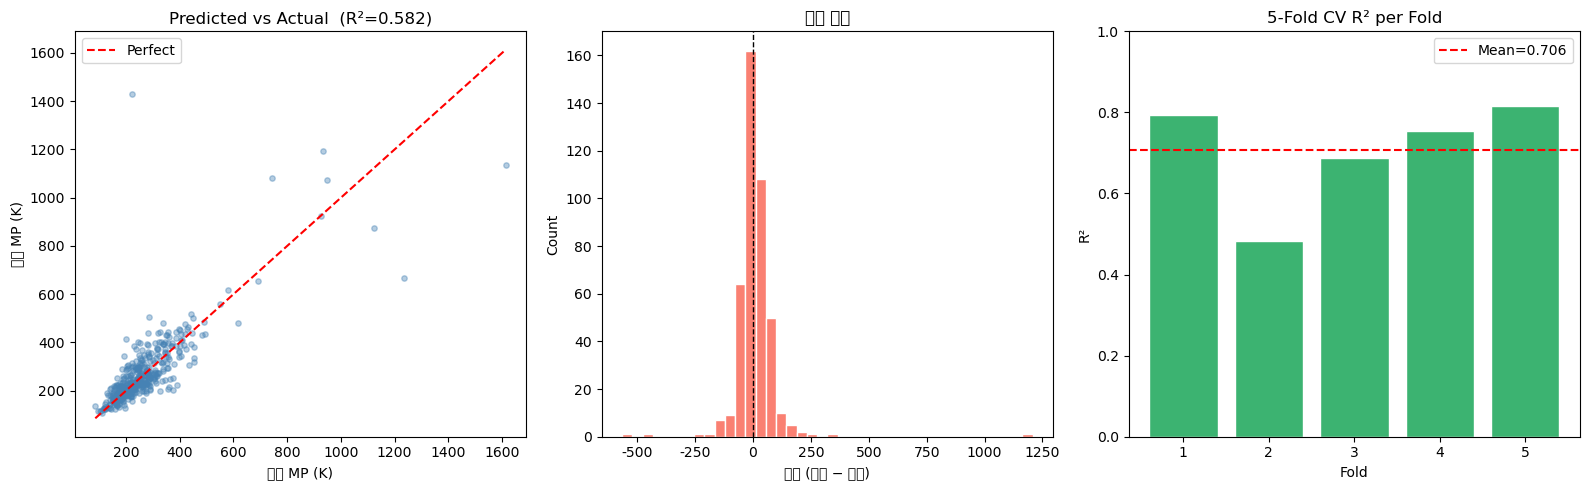

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("실제 MP (K)")
ax.set_ylabel("예측 MP (K)")
ax.set_title(f"Predicted vs Actual  (R²={test_r2:.3f})")
ax.legend()

ax = axes[1]
residuals = y_pred - y_test
ax.hist(residuals, bins=40, color="salmon", edgecolor="white")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("잔차 (예측 − 실제)")
ax.set_ylabel("Count")
ax.set_title("잔차 분포")

ax = axes[2]
ax.bar(range(1, 6), cv_r2, color="mediumseagreen", edgecolor="white")
ax.axhline(np.mean(cv_r2), color="red", linestyle="--", label=f"Mean={np.mean(cv_r2):.3f}")
ax.set_xlabel("Fold")
ax.set_ylabel("R²")
ax.set_title("5-Fold CV R² per Fold")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

## 8. 결과 요약

In [34]:
summary = pd.DataFrame({
    "구분":  ["5-Fold CV 평균", "Test Set"],
    "R²":   [f"{np.mean(cv_r2):.4f}", f"{test_r2:.4f}"],
    "MSE":  [f"{np.mean(cv_mse):.2f}", f"{test_mse:.2f}"],
    "MAE":  [f"{np.mean(cv_mae):.2f}", f"{test_mae:.2f}"],
})
print("=== 버전별 비교 ===")
print("base  CV R²: 0.5346  Test R²: 0.4831")
print("v2    CV R²: -       Test R²: -      (v2 실행 후 기입)")
print(f"v3ann CV R²: {np.mean(cv_r2):.4f}  Test R²: {test_r2:.4f}")
summary

=== 버전별 비교 ===
base  CV R²: 0.5346  Test R²: 0.4831
v2    CV R²: -       Test R²: -      (v2 실행 후 기입)
v3ann CV R²: 0.7065  Test R²: 0.5821


,구분,R²,MSE,MAE
0,5-Fold CV 평균,0.7065,7273.40,43.45
1,Test Set,0.5821,8132.73,46.35
